In [1]:
import os
import cv2
import re
import numpy as np
import matplotlib.pyplot as plt
import warnings
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
plt.style.use('default')

In [2]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

def compute_tsr_derivatives(thermal_seq, poly_degree=5):
    T, H, W = thermal_seq.shape
    time_steps = np.arange(1, T + 1)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        log_t = np.log(time_steps)
        log_T_flat = np.log(np.maximum(thermal_seq.reshape(T, -1), 1e-6))

    print(f"Fitting Polynomials (Degree {poly_degree}) across {H*W} pixels...")
    coeffs = np.polyfit(log_t, log_T_flat, deg=poly_degree)
    
    powers_d1 = np.arange(poly_degree, 0, -1)[:, np.newaxis]
    d1_coeffs = coeffs[:-1] * powers_d1
    
    powers_d2 = np.arange(poly_degree - 1, 0, -1)[:, np.newaxis]
    d2_coeffs = d1_coeffs[:-1] * powers_d2
    
    d1_frames, d2_frames = [], []

    for t_val in log_t:
        f1 = np.zeros(H * W)
        for c in d1_coeffs: 
            f1 = f1 * t_val + c
        d1_frames.append(f1.reshape(H, W))
        
        f2 = np.zeros(H * W)
        for c in d2_coeffs: 
            f2 = f2 * t_val + c
        d2_frames.append(f2.reshape(H, W))
        
    return np.stack(d1_frames).astype(np.float32), np.stack(d2_frames).astype(np.float32)

In [3]:
dataset_path = "./dataset/" 
orig_dir = os.path.join(dataset_path, 'originalData')
mask_dir = os.path.join(dataset_path, 'annotatedData')

orig_files = sorted([f for f in os.listdir(orig_dir) if not f.startswith('.')], key=natural_sort_key)
mask_files = sorted([f for f in os.listdir(mask_dir) if not f.startswith('.')], key=natural_sort_key)

thermal_list, mask_list = [], []

In [4]:
for fname in orig_files:
    img = cv2.imread(os.path.join(orig_dir, fname), cv2.IMREAD_GRAYSCALE)
    m_img = cv2.imread(os.path.join(mask_dir, fname), cv2.IMREAD_GRAYSCALE)
    
    thermal_list.append(img)
    
    _, binary = cv2.threshold(m_img, 1, 255, cv2.THRESH_BINARY)
    mask_list.append(binary / 255.0)

In [5]:
thermal_volume = np.stack(thermal_list, axis=0).astype(np.float32)
mask_volume = np.stack(mask_list, axis=0).astype(np.float32)

tsr_d1, tsr_d2 = compute_tsr_derivatives(thermal_volume)

Fitting Polynomials (Degree 5) across 54756 pixels...


In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), 
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), 
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

In [7]:
class PhysicsInformedUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.inc = DoubleConv(3, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(256, 128)
        
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(128, 64)
        
        self.outc = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        
        x = self.up1(x3)
        diffY = x2.size()[2] - x.size()[2]
        diffX = x2.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, 
                      diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x], dim=1)
        x = self.conv_up1(x)
        
        x = self.up2(x)
        diffY = x1.size()[2] - x.size()[2]
        diffX = x1.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, 
                      diffY // 2, diffY - diffY // 2])
        x = torch.cat([x1, x], dim=1)
        x = self.conv_up2(x)
        
        return self.outc(x)

In [8]:
class ThermoDataset(Dataset):
    def __init__(self, raw, d1, d2, masks): 
        self.raw, self.d1, self.d2, self.masks = raw, d1, d2, masks
    def __len__(self): 
        return len(self.raw)
    def __getitem__(self, i):
        x = np.stack([self.raw[i], self.d1[i], self.d2[i]], axis=0)
        y = self.masks[i][np.newaxis, ...]
        return torch.from_numpy(x), torch.from_numpy(y)

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [10]:
model = PhysicsInformedUNet().to(device)

criterion = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

dataset = ThermoDataset(thermal_volume, tsr_d1, tsr_d2, mask_volume)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

epochs = 20
loss_history = []

In [11]:
scaler = torch.amp.GradScaler('cuda')

for epoch in range(epochs):
    epoch_loss = 0
    model.train()

    for batch_idx, (data, target) in enumerate(loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            output = model(data)
            loss = criterion(output, target)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{epochs} - Average Loss: {avg_loss:.4f}")

Epoch 01/20 - Average Loss: 0.2943
Epoch 02/20 - Average Loss: 0.0980
Epoch 03/20 - Average Loss: 0.0467
Epoch 04/20 - Average Loss: 0.0266
Epoch 05/20 - Average Loss: 0.0174
Epoch 06/20 - Average Loss: 0.0121
Epoch 07/20 - Average Loss: 0.0092
Epoch 08/20 - Average Loss: 0.0072
Epoch 09/20 - Average Loss: 0.0060
Epoch 10/20 - Average Loss: 0.0046
Epoch 11/20 - Average Loss: 0.0039
Epoch 12/20 - Average Loss: 0.0035
Epoch 13/20 - Average Loss: 0.0030
Epoch 14/20 - Average Loss: 0.0026
Epoch 15/20 - Average Loss: 0.0023
Epoch 16/20 - Average Loss: 0.0022
Epoch 17/20 - Average Loss: 0.0019
Epoch 18/20 - Average Loss: 0.0019
Epoch 19/20 - Average Loss: 0.0015
Epoch 20/20 - Average Loss: 0.0014


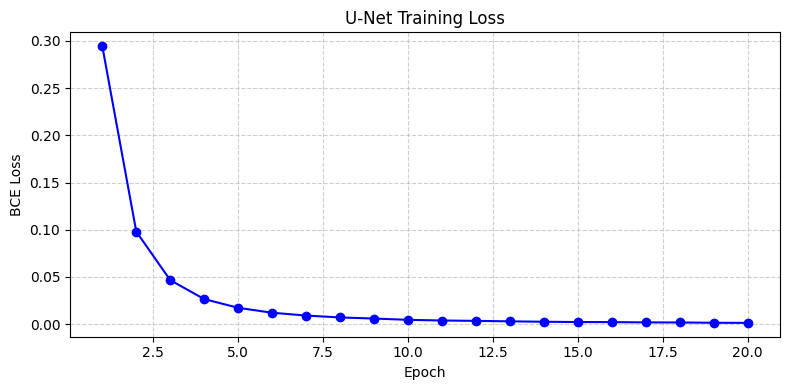

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', color='b')
plt.title("U-Net Training Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [13]:
model.eval()

total_frames = len(thermal_volume)
test_indices = [
    int(total_frames * 0.15),
    int(total_frames * 0.25),
    int(total_frames * 0.50)
]

In [14]:
predictions = []

with torch.no_grad():
    for idx in test_indices:
        sample_in = torch.from_numpy(np.stack([
            thermal_volume[idx], 
            tsr_d1[idx], 
            tsr_d2[idx]
        ], axis=0)).unsqueeze(0).to(device)

        pred_probs = torch.sigmoid(model(sample_in)).cpu().squeeze().numpy()
        pred_mask = (pred_probs > 0.5).astype(np.float32)
        predictions.append(pred_mask)

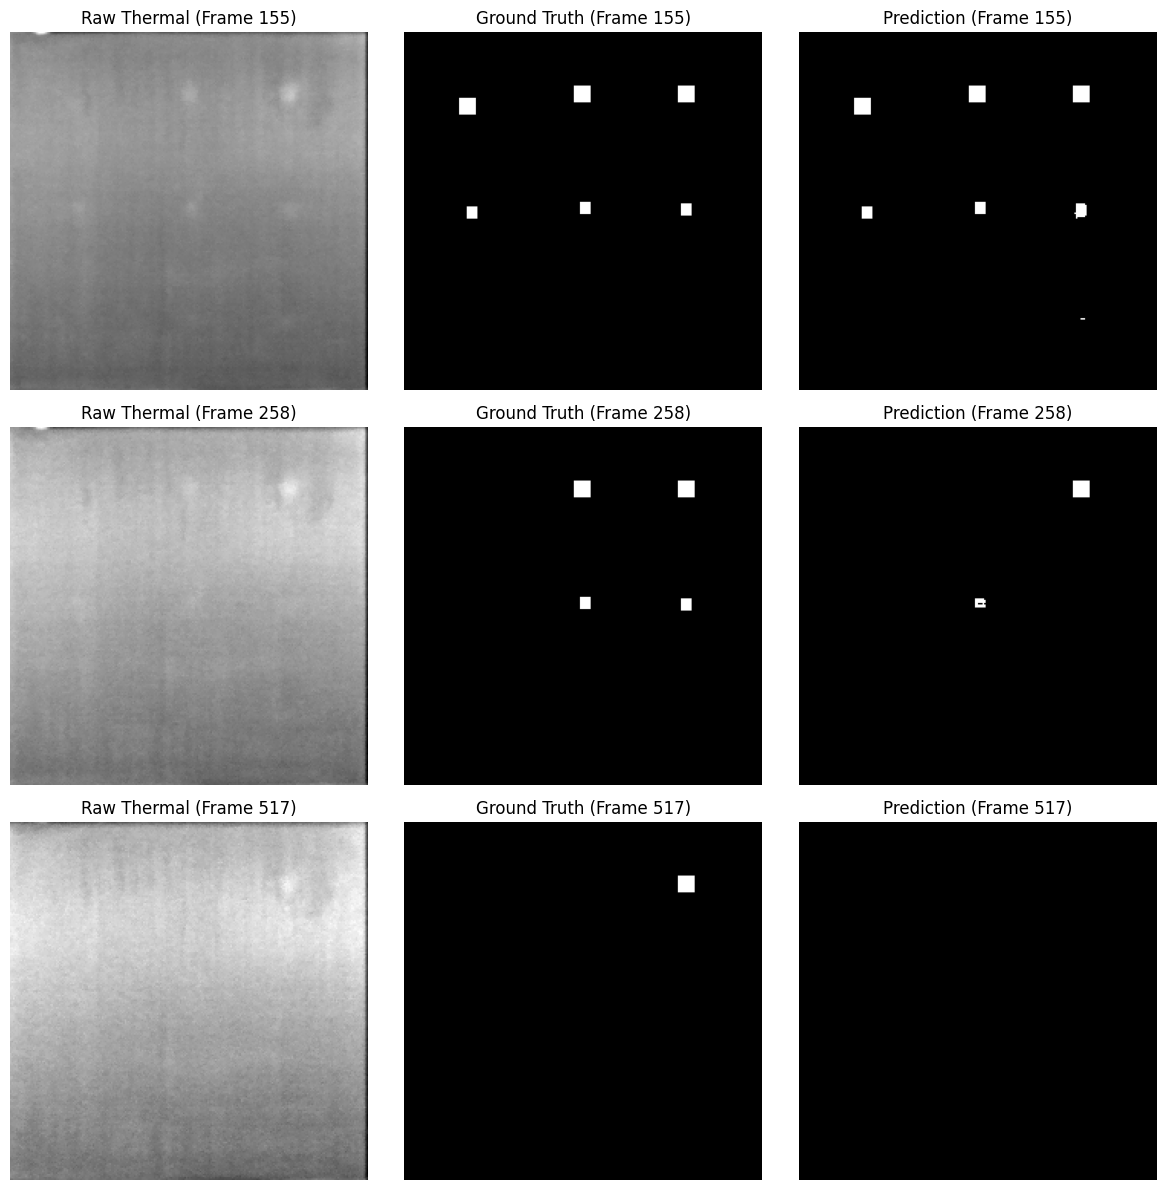

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row, idx in enumerate(test_indices):
    axes[row, 0].imshow(thermal_volume[idx], cmap='gray')
    axes[row, 0].set_title(f"Raw Thermal (Frame {idx})")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask_volume[idx], cmap='gray')
    axes[row, 1].set_title(f"Ground Truth (Frame {idx})")
    axes[row, 1].axis('off')

    axes[row, 2].imshow(predictions[row], cmap='gray')
    axes[row, 2].set_title(f"Prediction (Frame {idx})")
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()